<a href="https://colab.research.google.com/github/Aman-5011/ML_100days_campusx/blob/main/decision-tree/Data_Science_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
#To build and evaluate a Decision Tree classifier using the Iris dataset,
#and analyze its performance on training and testing data to study decision boundaries,
#model interpretability, and overfitting behavior.

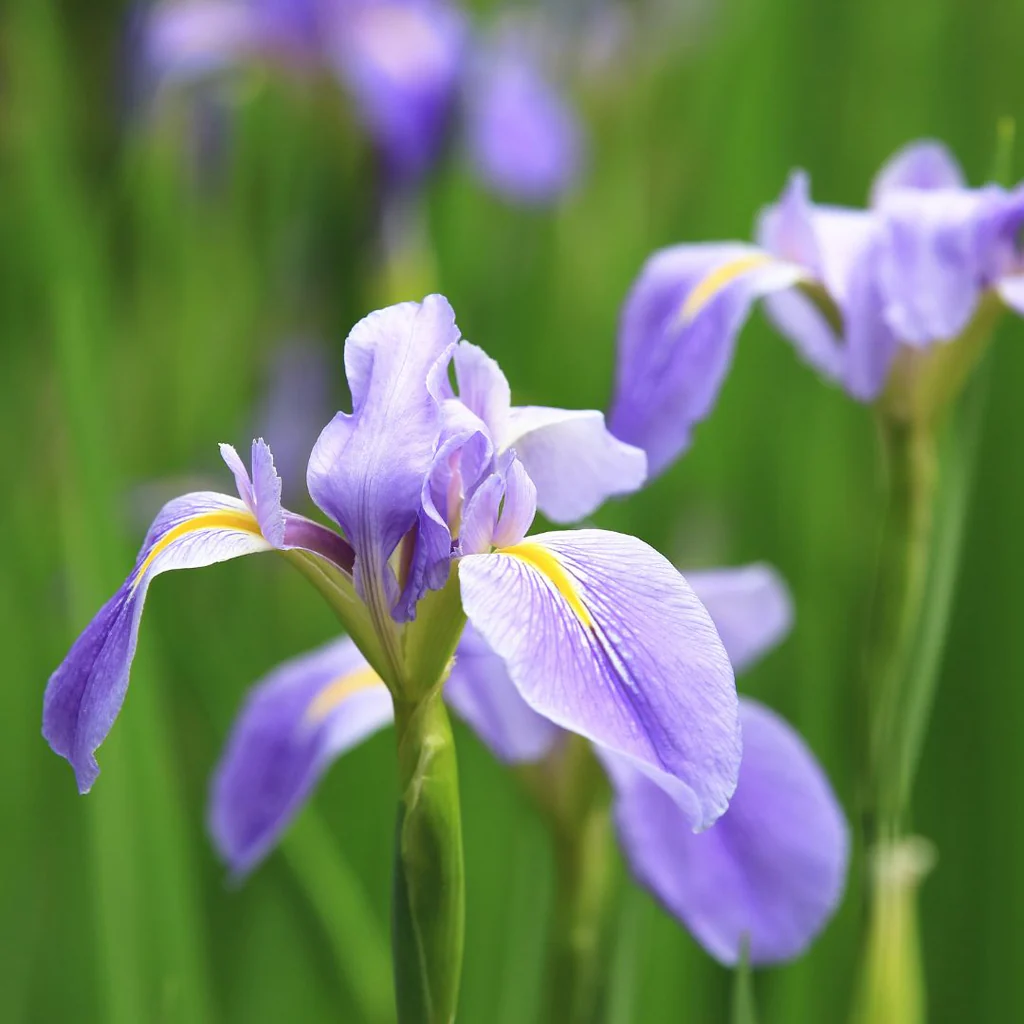

# **Data Analysis**

In [15]:
import pandas as pd
import numpy as np

In [28]:
from sklearn.datasets import load_iris
iris=load_iris()
df=pd.DataFrame(iris.data,columns=iris.feature_names)
df['target']=iris.target
#loaded dataset and converted it to dataframe so that we can use pandas to analyse it

In [29]:
df.shape

(150, 5)

In [19]:
df.sample(8)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
50,7.0,3.2,4.7,1.4,1
52,6.9,3.1,4.9,1.5,1
78,6.0,2.9,4.5,1.5,1
24,4.8,3.4,1.9,0.2,0
11,4.8,3.4,1.6,0.2,0
111,6.4,2.7,5.3,1.9,2
139,6.9,3.1,5.4,2.1,2
68,6.2,2.2,4.5,1.5,1


In [20]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [22]:
df.corr()
#we can notice petal length and petal width are highly correlated
#sepal width weakly correlated with target
#so usually we remove highly correlated columns from dataset

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
sepal length (cm),1.000000,-0.117570,0.871754,0.817941,0.782561
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126,-0.426658
petal length (cm),0.871754,-0.428440,1.000000,0.962865,0.949035
petal width (cm),0.817941,-0.366126,0.962865,1.000000,0.956547
target,0.782561,-0.426658,0.949035,0.956547,1.000000


In [23]:
df.groupby('target').mean()
#we can notice petal length and width are very different across classes
#but sepal width overlaps a lot

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
target,,,,
0,5.006,3.428,1.462,0.246
1,5.936,2.770,4.260,1.326
2,6.588,2.974,5.552,2.026


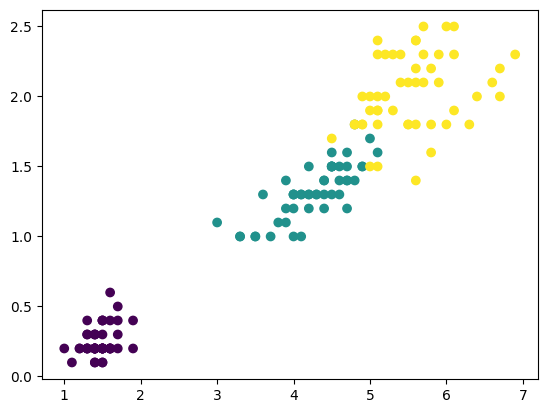

In [34]:
import matplotlib.pyplot as plt
plt.scatter(df['petal length (cm)'], df['petal width (cm)'], c=df['target'])
#we can notice almost a perfect sepration

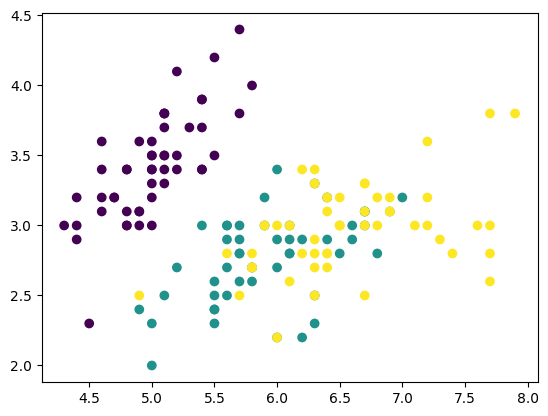

In [35]:
plt.scatter(df['sepal length (cm)'], df['sepal width (cm)'], c=df['target'])
#Heavy overlap

In [36]:
#so in the iris dataset, petal length and petal width are the most important features as they clearly distinguish between classes.
#Sepal features, especially sepal width, are less informative due to overlap between classes,
#but they are not entirely useless and can still contribute to model performance.


In [ ]:
#also no missing data is there so no imputing of data and we know that normalization not required for decision trees

# **Creating Model and Finding Accuracy**

In [54]:
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
x=iris.data
y=iris.target

In [55]:
xtr,xts,ytr,yts=train_test_split(x,y,test_size=0.2,random_state=42)

LETS COMPARE **GINI** VRS **ENTROPY**



*   Using Gini Index





In [56]:
gini_model = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
gini_model.fit(xtr, ytr)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [57]:
gini_train = accuracy_score(ytr, gini_model.predict(xtr))
gini_test = accuracy_score(yts, gini_model.predict(xts))

gini_cv = cross_val_score(gini_model, x,y, cv=5)



*   Using Entropy



In [58]:
entropy_model = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
entropy_model.fit(xtr, ytr)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

In [60]:
entropy_train = accuracy_score(ytr, entropy_model.predict(xtr))
entropy_test = accuracy_score(yts, entropy_model.predict(xts))

entropy_cv = cross_val_score(entropy_model, x, y, cv=5)

In [61]:
#result
print("Gini     -> Train:", gini_train, " Test:", gini_test, " CV Mean:", gini_cv.mean())
print("Entropy  -> Train:", entropy_train, " Test:", entropy_test, " CV Mean:", entropy_cv.mean())

Gini     -> Train: 0.9583333333333334  Test: 1.0  CV Mean: 0.9733333333333334
Entropy  -> Train: 0.9583333333333334  Test: 1.0  CV Mean: 0.96


In [ ]:
#Cross-validation scores for Gini and Entropy are almost identical
# so here criterion choice has minimal impact, depth matters more

# Overfitting and Underfitting

In [ ]:
#overfitting and underfitting can depend on several parameters like max_depth,max_sample_split,min_sample_leaf,max_features etc


*  Lets visualise it using max_depth



In [72]:
from sklearn.tree import plot_tree
def visualize_tree(max_depth):

    # Use only first 2 features
    X_vis = x[:, :2]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_vis, y, test_size=0.2, random_state=42
    )

    model = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    model.fit(X_train, y_train)

    # ---- Accuracy ----
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))

    # ---- Decision Boundary ----
    x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
    y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.02),
        np.arange(y_min, y_max, 0.02)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(12, 5))

    # Boundary plot
    plt.subplot(1, 2, 1)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y, edgecolor='k')
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(f"Boundary (depth={max_depth})\nTrain={train_acc:.2f}, Test={test_acc:.2f}")

    # Tree plot
    plt.subplot(1, 2, 2)
    plot_tree(model, filled=True)

    plt.title(f"Decision Tree (depth={max_depth})")
    plt.tight_layout()
    plt.show()

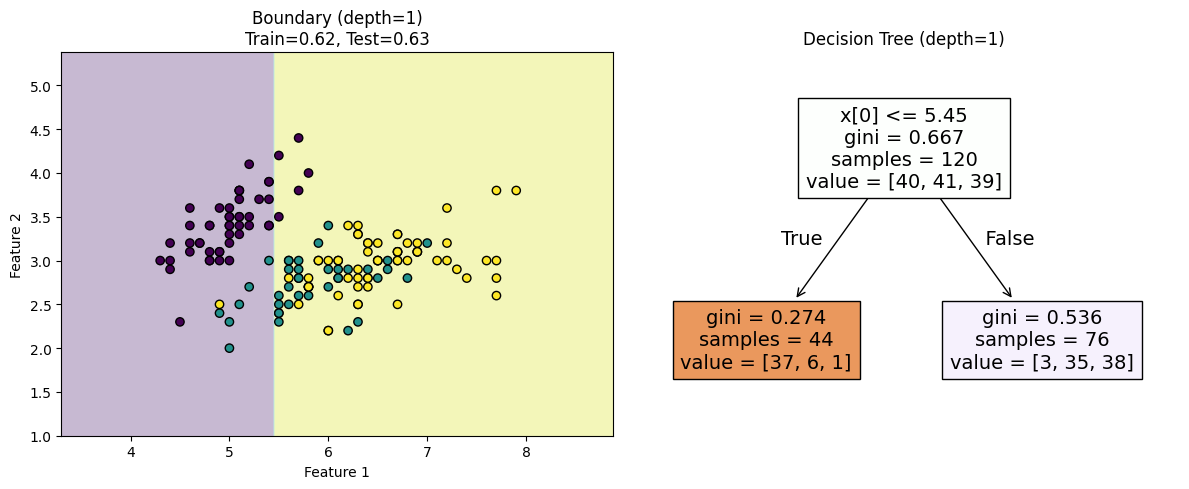

In [74]:
visualize_tree(max_depth=1) #it is the case of underfitting
#model do not learn well from training data because only have one decision boundary
#accuracy is low for both training and testing data ,it shows case of underfitting

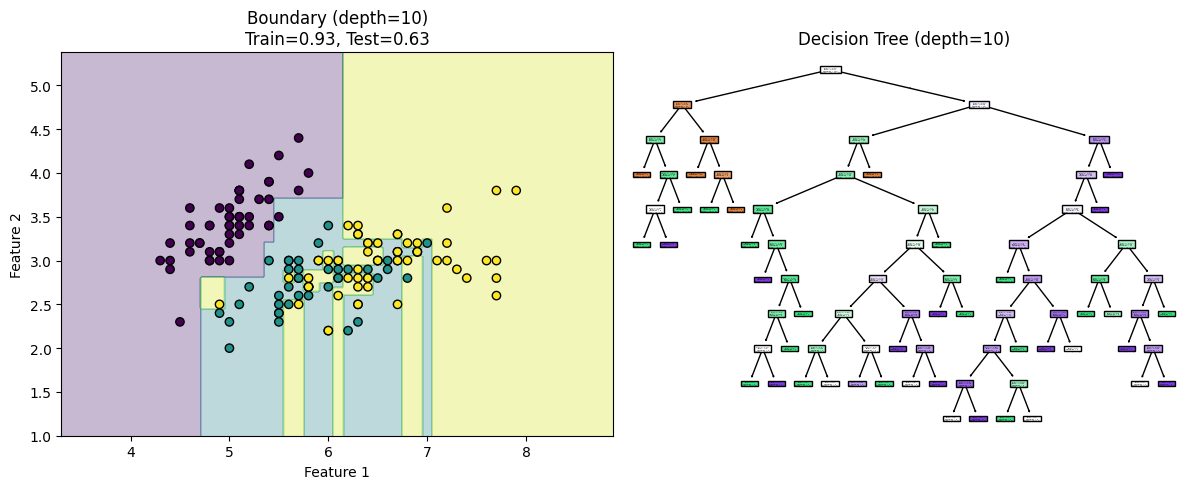

In [75]:
visualize_tree(max_depth=10) #it is the case of overfitting
#model trying to mug up training data
#we can see accuracy for training data is higher but bad for testing data ,it shows overfitting of data

* **Lets check accuracy difference on using random splitter and using best splitter**

In [77]:
# Models
model_best = DecisionTreeClassifier(max_depth=3, splitter='best', random_state=42)
model_random = DecisionTreeClassifier(max_depth=3, splitter='random', random_state=42)

In [78]:
# Train
model_best.fit(xtr, ytr)
model_random.fit(xtr, ytr)

# Accuracy
best_train = accuracy_score(ytr, model_best.predict(xtr))
best_test = accuracy_score(yts, model_best.predict(xts))

rand_train = accuracy_score(ytr, model_random.predict(xtr))
rand_test = accuracy_score(yts, model_random.predict(xts))

print("BEST    -> Train:", best_train, " Test:", best_test)
print("RANDOM  -> Train:", rand_train, " Test:", rand_test)

BEST    -> Train: 0.9583333333333334  Test: 1.0
RANDOM  -> Train: 0.95  Test: 1.0


In [79]:

print("BEST CV:", cross_val_score(model_best, x, y, cv=5).mean())
print("RANDOM CV:", cross_val_score(model_random, x, y, cv=5).mean())

BEST CV: 0.9733333333333334
RANDOM CV: 0.9533333333333334


In [80]:
#random splitter is sometimes useful for avoiding overfitting
#but here no much difference is seen
#crossvalscore of best is performing slightly better

*   Lets check accuracy difference on changing min_sample_split

In [81]:
#Increasing min_samples_split reduces overfitting but too large value causes underfitting.
#so its sets a min limit of samples required to split.
#it is used to prevent less important splits in the tree

# Small value → high train accuracy (overfitting tendency)
# Medium → balanced
# Large → accuracy drops (underfitting)

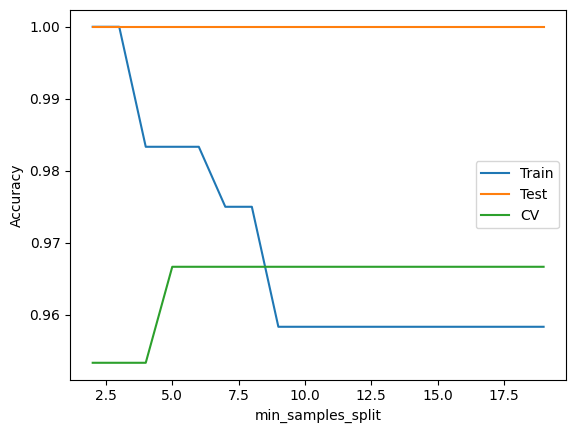

In [87]:
splits = range(2, 20)

train_scores = []
test_scores = []
cv_scores = []

for s in splits:
    model = DecisionTreeClassifier(min_samples_split=s, random_state=42)
    model.fit(xtr, ytr)

    train_scores.append(accuracy_score(ytr, model.predict(xtr)))
    test_scores.append(accuracy_score(yts, model.predict(xts)))
    cv_scores.append(cross_val_score(model, x, y, cv=5).mean())

# Plot
plt.plot(splits, train_scores, label='Train')
plt.plot(splits, test_scores, label='Test')
plt.plot(splits, cv_scores, label='CV')
plt.xlabel('min_samples_split')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [88]:
#so we can notice when min_sample_split value is increasing the underfitting of data increased ,so accuracy on train data decreases
#but test data accuracy intact because dataset is too easy

*   Effect of **min_impurity_decrease** on accuracy


impurity=0.0
Train: 1.000, Test: 1.000, CV: 0.953

impurity=0.001
Train: 1.000, Test: 1.000, CV: 0.953

impurity=0.01
Train: 0.992, Test: 1.000, CV: 0.967

impurity=0.05
Train: 0.950, Test: 0.967, CV: 0.933

impurity=0.1
Train: 0.950, Test: 0.967, CV: 0.933



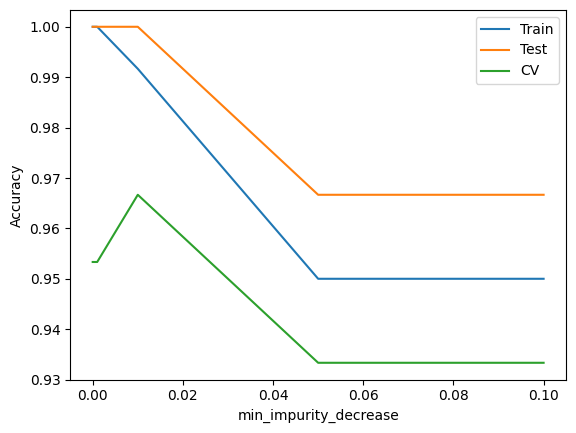

In [90]:
# Try different impurity thresholds
imp_values = [0.0, 0.001, 0.01, 0.05, 0.1]

train_scores = []
test_scores = []
cv_scores = []

for imp in imp_values:
    model = DecisionTreeClassifier(min_impurity_decrease=imp, random_state=42)
    model.fit(xtr, ytr)

    train_scores.append(accuracy_score(ytr, model.predict(xtr)))
    test_scores.append(accuracy_score(yts, model.predict(xts)))
    cv_scores.append(cross_val_score(model, x, y, cv=5).mean())

    print(f"impurity={imp}")
    print(f"Train: {train_scores[-1]:.3f}, Test: {test_scores[-1]:.3f}, CV: {cv_scores[-1]:.3f}\n")

# Plot
plt.plot(imp_values, train_scores, label='Train')
plt.plot(imp_values, test_scores, label='Test')
plt.plot(imp_values, cv_scores, label='CV')
plt.xlabel('min_impurity_decrease')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
#Increasing min_impurity_decrease makes the tree more conservative by allowing only meaningful splits,
#reducing overfitting but risking underfitting if too large.

#conclusion
# Increasing min_impurity_decrease makes the tree more selective in splitting
# Small values (≈ 0 to 0.01) help remove weak/noisy splits → better generalization
# Large values restrict splits too much → underfitting
# Default value (0.0) allows all splits → may lead to overfitting

So there are several other important parameters on which accuracy and overfitting and underfitting of data depends apart from max_depth , splitter ,min_sample_split,min_impurity_decrease that we have already seen


*   min_sample_leaf = ensures a minimum number of samples in each leaf, making it a stronger constraint against overfitting.

*   max_features=It controls how many features the model is allowed to consider at each split

*   max_leaf_node=Limits the maximum number of leaf nodes in the tree






# ***Introduction to dtreeviz***

In [119]:
#dtreeviz is a Python library used to visually explain Decision Tree models in a clear and intuitive way.

In [111]:
import graphviz.backend as be
import dtreeviz
from IPython.display import Image, display_svg, SVG

In [112]:
clas = DecisionTreeClassifier()

X_train = iris.data
y_train = iris.target
clas.fit(X_train, y_train)

DecisionTreeClassifier()

# Classification

In [126]:
import warnings
import logging

warnings.filterwarnings("ignore")
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

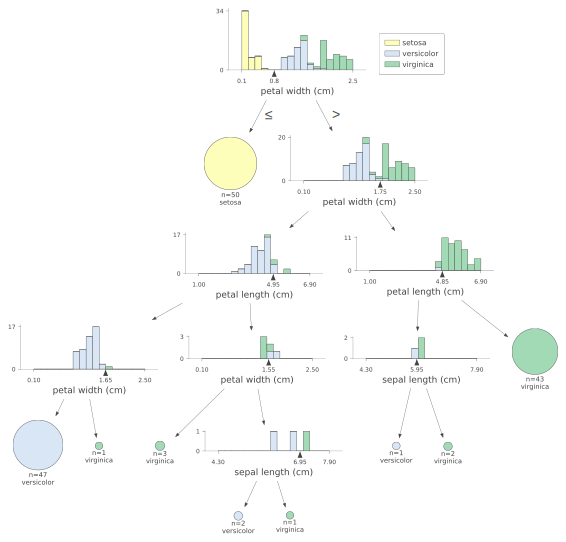

In [127]:
plt.rcParams['font.family'] = 'DejaVu Sans'
from dtreeviz import model

viz = model(
    clas,
    X_train,
    y_train,
    feature_names=iris.feature_names,
    class_names=["setosa", "versicolor", "virginica"]
)

viz.view()

# **Show Node number**

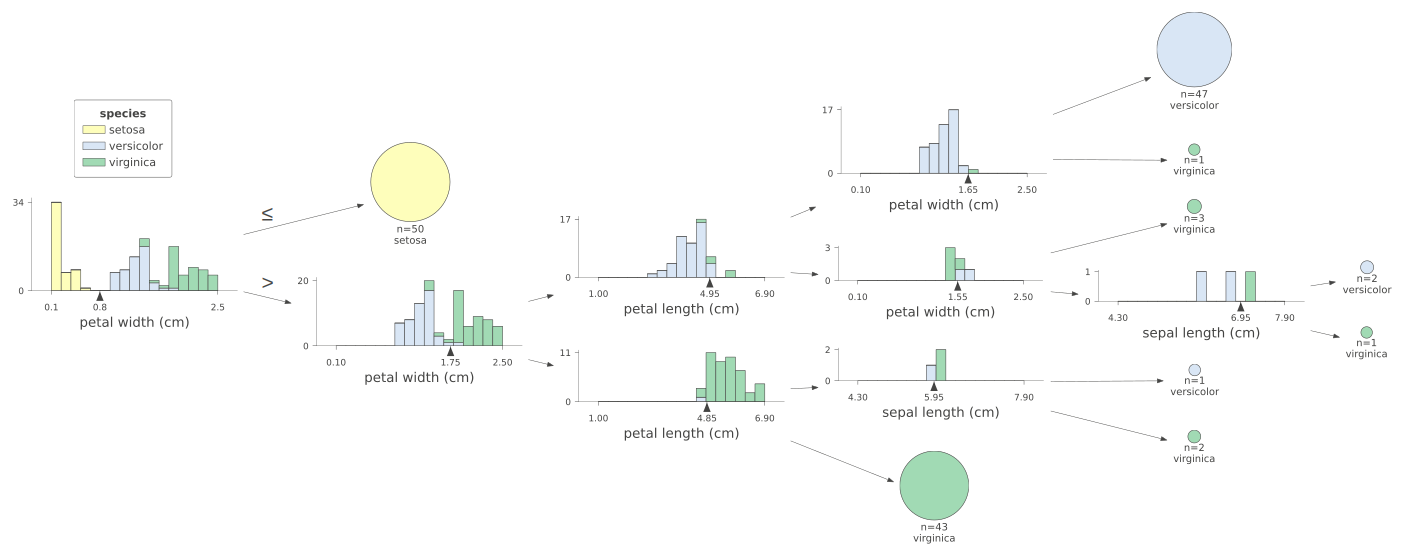

In [128]:
viz = model(
    clas,
    X_train,
    y_train,
    target_name='species',   # not 'price' (fix this)
    feature_names=iris.feature_names,
    class_names=["setosa", "versicolor", "virginica"]
)

viz.view(
    orientation="LR",      # left-to-right tree
    scale=1.5              # zoom
)